In [19]:
import dataset_prov as ds
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D

In [20]:
# Primary Only
ds_primary = ds.build_dataset("../Data/PrimaryOnly/Uniform", max_files=100, primary_only=True, target=["energy", "cublet"])

data_p = np.array([d[1] for d in ds_primary])

p_energy = data_p[:, 0]
p_ids    = data_p[:, 1].astype(int)

# Coordenadas Primary
p_z = p_ids // 100
p_y = (p_ids % 100) // 10
p_x = p_ids % 10

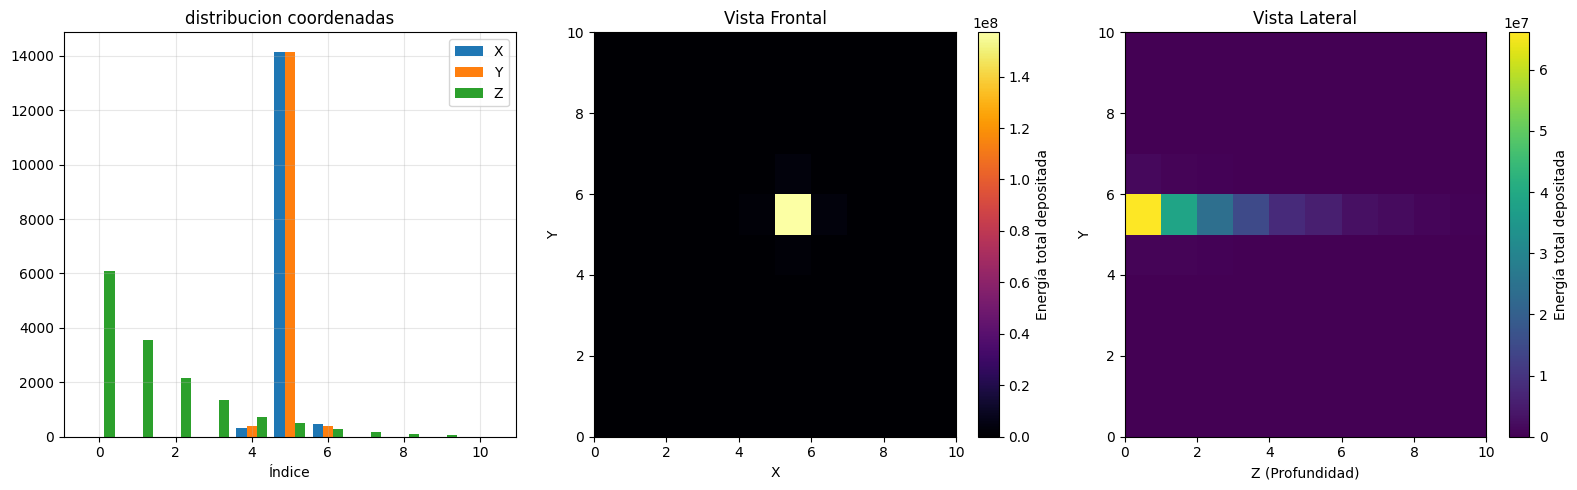

In [21]:
fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.hist([p_x, p_y, p_z], bins=np.arange(0, 12)-0.5, label=['X', 'Y', 'Z'], 
          linewidth=2, density=False)
#histtype=step
ax1.set_title("distribucion coordenadas")
ax1.set_xlabel("Índice"); ax1.legend(); ax1.grid(alpha=0.3)


ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(p_x, p_y, weights=p_energy, bins=[np.arange(11), np.arange(11)], cmap='inferno')
fig.colorbar(h2[3], ax=ax2, label='Energía total depositada')
ax2.set_title("Vista Frontal")
ax2.set_xlabel("X"); ax2.set_ylabel("Y")


ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(p_z, p_y, weights=p_energy, bins=[np.arange(11), np.arange(11)], cmap='viridis')
fig.colorbar(h3[3], ax=ax3, label='Energía total depositada')
ax3.set_title("Vista Lateral")
ax3.set_xlabel("Z (Profundidad)"); ax3.set_ylabel("Y")

#weight indicates, what are we adding in the bins (or in the heatmap). 

plt.tight_layout()
plt.show()

Here, we clearly see that the primary cubelet is not necesarily in the first layer 

In [22]:
#All
ds_all = ds.build_dataset("../Data/All", max_files=20, primary_only=False, target=["energy", "cublet", "primary"])

eventos_completos = [] 
e_flat = [] 
ids_flat = []

current_e = np.zeros(1000)
current_p = np.zeros(1000, dtype=int)
ultimo_id = -1

#The amount of files that we have read isnt a multiple of 10000, which means, we cant arbitrarly determine the set of 1000 cublets, by cutting each 1000 files.
#instead, what we are going to do, is count the cublet_id and we are going to stop and reset each time we read a cublet_id that is either larger than 999, or 
#smaller than the previous one. Of course this hypothesis only works if we assume that the cublets are placed in order. 

for d in ds_all:
    energy, cublet_id, is_primary = d[1]
    
    if cublet_id <= ultimo_id:
        eventos_completos.append((current_e, current_p))
        current_e, current_p = np.zeros(1000), np.zeros(1000, dtype=int)
    
    if 0 <= cublet_id < 1000:
        current_e[cublet_id] = energy
        current_p[cublet_id] = is_primary
    
    ultimo_id = cublet_id
eventos_completos.append((current_e, current_p))
#Up until now, we have N events with m cubelets asigned.



indices = np.arange(1000)
coords_todas = np.column_stack([
    indices % 10,           # X
    (indices % 100) // 10,  # Y
    indices // 100          # Z
])

all_distances = []
all_energies = []


for e_map, p_map in eventos_completos:
    # we look for the primary cubelet, asuming we have only one.
    
    ip = np.where(p_map == 1)[0][0]
    p_coord = coords_todas[ip] 
    distancias_evento = np.linalg.norm(coords_todas - p_coord, axis=1)
    
    all_distances.append(distancias_evento)
    all_energies.append(e_map)


all_distances = np.concatenate(all_distances)
all_energies = np.concatenate(all_energies)

print(f"Tenemos {len(eventos_completos)} sucesos.")

Tenemos 60 sucesos.


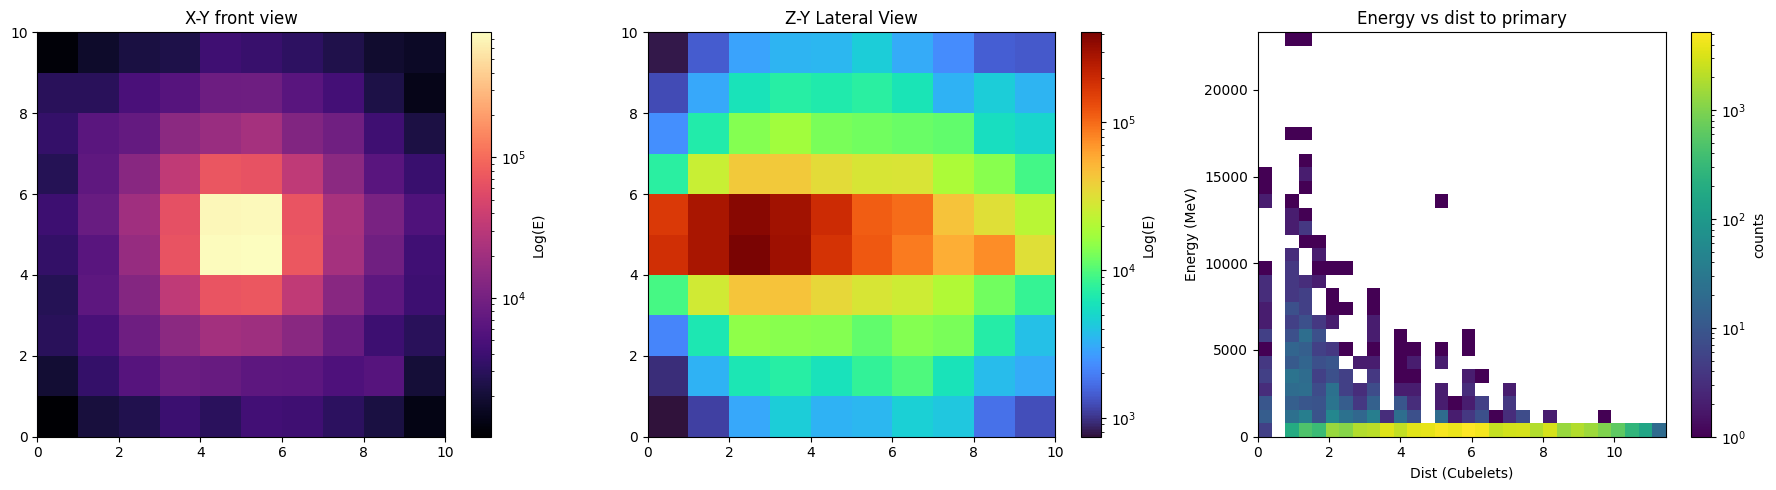

In [24]:
mask = all_energies > 0
dist_plot = all_distances[mask]
ener_plot = all_energies[mask]

#now we use the procesed data to create a few plots to take a look into the energy distribution.
data_a = np.array([d[1] for d in ds_all])
a_energy, a_ids = data_a[:, 0], data_a[:, 1].astype(int)
a_z, a_y, a_x = a_ids // 100, (a_ids % 100) // 10, a_ids % 10

fig = plt.figure(figsize=(18, 5))

# (X vs Y)
ax1 = fig.add_subplot(1, 3, 1)
h1 = ax1.hist2d(a_x, a_y, weights=a_energy, bins=[np.arange(11), np.arange(11)], cmap='magma', norm=LogNorm())
plt.colorbar(h1[3], ax=ax1, label='Log(E)')
ax1.set_title("X-Y front view")

# (Z vs Y)
ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(a_z, a_y, weights=a_energy, bins=[np.arange(11), np.arange(11)], cmap='turbo', norm=LogNorm())
plt.colorbar(h2[3], ax=ax2, label='Log(E)')
ax2.set_title("Z-Y Lateral View")

#energy vs distance
ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(all_distances, all_energies, bins=30, cmap='viridis', norm=LogNorm())
plt.colorbar(h3[3], ax=ax3, label='counts')
ax3.set_title("Energy vs dist to primary")
ax3.set_xlabel("Dist (Cubelets)"); ax3.set_ylabel("Energy (MeV)")

plt.tight_layout()
plt.show()

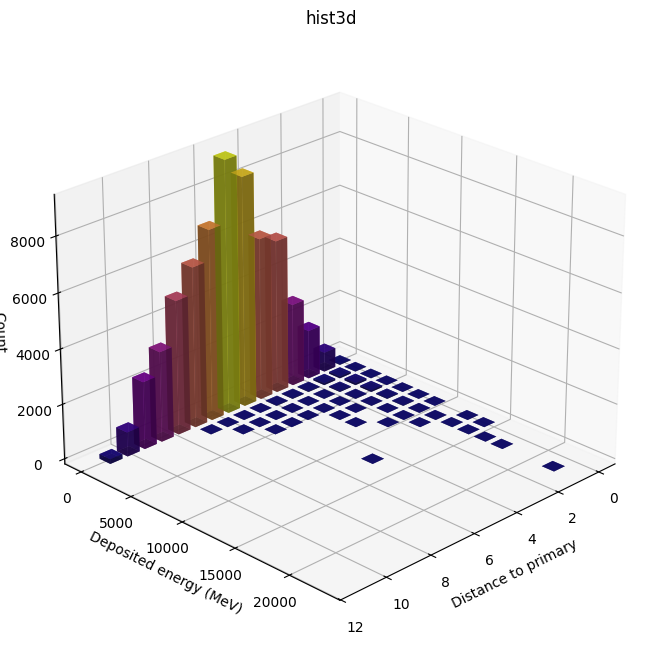

In [27]:
#We try to repeat the last plot, in 3d
nbins_dist = 15
nbins_ener = 15


hist, d_edges, e_edges = np.histogram2d(all_distances, all_energies, bins=[nbins_dist, nbins_ener])


d_pos, e_pos = np.meshgrid(d_edges[:-1], e_edges[:-1], indexing="ij")
d_pos = d_pos.ravel()
e_pos = e_pos.ravel()
z_pos = np.zeros_like(d_pos)


dd = np.ones_like(z_pos) * (d_edges[1] - d_edges[0]) * 0.7
de = np.ones_like(z_pos) * (e_edges[1] - e_edges[0]) * 0.7
dz = hist.ravel() # Altura = Conteos


mask = dz > 0
d_f, e_f, z_f, dd_f, de_f, dz_f = d_pos[mask], e_pos[mask], z_pos[mask], dd[mask], de[mask], dz[mask]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


colors = plt.cm.plasma(dz_f / dz_f.max())

ax.bar3d(d_f, e_f, z_f, dd_f, de_f, dz_f, color=colors, shade=True, alpha=0.8)

ax.set_title("hist3d")
ax.set_xlabel("Distance to primary")
ax.set_ylabel("Deposited energy (MeV)")
ax.set_zlabel("Count")

ax.view_init(elev=25, azim=45)
plt.show()

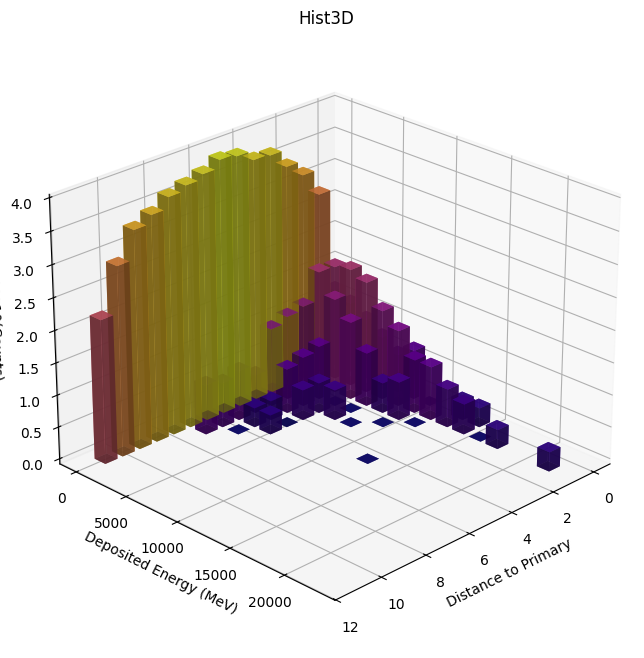

In [28]:
#same plot with logaritmic scale on the counts

nbins_dist = 15
nbins_ener = 15

# Histograma 2D original
hist, d_edges, e_edges = np.histogram2d(all_distances, all_energies, bins=[nbins_dist, nbins_ener])


dz = hist.ravel()
mask = dz > 0


d_pos, e_pos = np.meshgrid(d_edges[:-1], e_edges[:-1], indexing="ij")
d_f = d_pos.ravel()[mask]
e_f = e_pos.ravel()[mask]
z_f = np.zeros_like(d_f)


dz_log = np.log10(dz[mask])


dd_f = np.ones_like(dz_log) * (d_edges[1] - d_edges[0]) * 0.7
de_f = np.ones_like(dz_log) * (e_edges[1] - e_edges[0]) * 0.7


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


colors = plt.cm.plasma(dz_log / dz_log.max())

ax.bar3d(d_f, e_f, z_f, dd_f, de_f, dz_log, color=colors, shade=True, alpha=0.8)


ax.set_title("Hist3D")
ax.set_xlabel("Distance to Primary")
ax.set_ylabel("Deposited Energy (MeV)")
ax.set_zlabel("Log10(Counts)")

ax.view_init(elev=25, azim=45)
plt.show()

I find it really difficult to extract from this plot any kind of classification that we could apply to the cubelets. *(The plots could even be wrong)*

We have a few observations to make though: The primary cubelet is not always in the first layer. And assuming the chosen method is correct, the primary cubelets arent necessarily the ones with the most energy deposited in them. 

This is quite weird so for now, my guess is that the code isnt appropiate.